## Pitchfork Reviews
Loads the Pitchfork SQLite database into a pandas DataFrame.


In [2]:
import sqlite3
from pathlib import Path

import pandas as pd

DB_PATH = Path("/Users/jamesemcnally/Dropbox/DLBC/data.sqlite3")
DATA_DIR = Path("../datasets")

## Loading Data

NB: this is from a local file; later I'll update this to include steps to download directly from Kaggle using their API

In [3]:
with sqlite3.connect(DB_PATH) as conn:
    reviews = pd.read_sql_query("SELECT review_url, is_standard_review, pub_date, body FROM reviews", conn)
    tombstones = pd.read_sql_query("SELECT review_url, group_concat(title, ', ') AS title, group_concat(score, ', ') AS score FROM tombstones GROUP BY review_url", conn)
    artists = pd.read_sql_query("SELECT arm.review_url, group_concat(a.name, ', ') AS artist, count(*) AS artist_count FROM artist_review_map arm JOIN artists a ON a.artist_id = arm.artist_id GROUP BY arm.review_url", conn)
    genres = pd.read_sql_query("SELECT review_url, group_concat(genre, ', ') AS genres FROM genre_review_map GROUP BY review_url", conn)
    authors = pd.read_sql_query("SELECT review_url, group_concat(author, ', ') AS author FROM author_review_map GROUP BY review_url", conn)

df = (reviews.merge(tombstones, on="review_url").merge(artists, on="review_url", how="left")
      .merge(genres, on="review_url", how="left").merge(authors, on="review_url", how="left"))

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24169 entries, 0 to 24168
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   review_url          24169 non-null  object
 1   is_standard_review  24169 non-null  int64 
 2   pub_date            24169 non-null  object
 3   body                24169 non-null  object
 4   title               24169 non-null  object
 5   score               24169 non-null  object
 6   artist              24169 non-null  object
 7   artist_count        24169 non-null  int64 
 8   genres              21819 non-null  object
 9   author              24169 non-null  object
dtypes: int64(2), object(8)
memory usage: 1.8+ MB


In [4]:
# Quick look at the first two rows.
df.head(2)


,review_url,is_standard_review,pub_date,body,title,score,artist,artist_count,genres,author
0,/reviews/albums/9232-vesikansi/,1,2006-07-27 06:00:04,"Over the past few years, several of Finland's ...",Vesikansi,7.1,Avarus,1,"Experimental, Rock",Matthew Murphy
1,/reviews/albums/22823-elsewhere/,1,2017-01-27 06:00:00,It's hard not to root for Pinegrove. Even befo...,Elsewhere,7.5,Pinegrove,1,Rock,Sam Sodomsky


## Data Cleaning


In [5]:
# Convert pub_date to datetime, drop duplicates, and filter to single-album reviews with clean scores.
df["pub_date"] = pd.to_datetime(df["pub_date"], utc=True).dt.date
df = df.drop_duplicates(subset=["body"])
df = df[df["artist_count"] == 1]
df = df[~df["score"].str.contains(",", na=False)]
df["score"] = pd.to_numeric(df["score"])
print(f"{len(df):,} reviews after cleaning")


22,857 reviews after cleaning


## Cleaning Text


In [6]:
# Strip HTML tags and entities, normalize whitespace.
import html, re

df["cleaned_body"] = df["body"].str.replace(r"<[^>]+>", "", regex=True)
df["cleaned_body"] = df["cleaned_body"].apply(html.unescape)
df["cleaned_body"] = df["cleaned_body"].str.replace(r"\s+", " ", regex=True).str.strip()


## Basic Text Analysis


In [9]:
# Add word count, character count, sentence count, and TextBlob sentiment.

!pip install textblob --quiet

from textblob import TextBlob

df["word_count"] = df["cleaned_body"].str.split().str.len()
df["char_count"] = df["cleaned_body"].str.len()
df["sentence_count"] = df["cleaned_body"].str.count(r"\.")
df["sentiment_score"] = df["cleaned_body"].apply(lambda x: TextBlob(x).sentiment.polarity)
df["sentiment_category"] = df["sentiment_score"].apply(lambda x: "positive" if x > 0 else "negative" if x < 0 else "neutral")


### Length Distributions


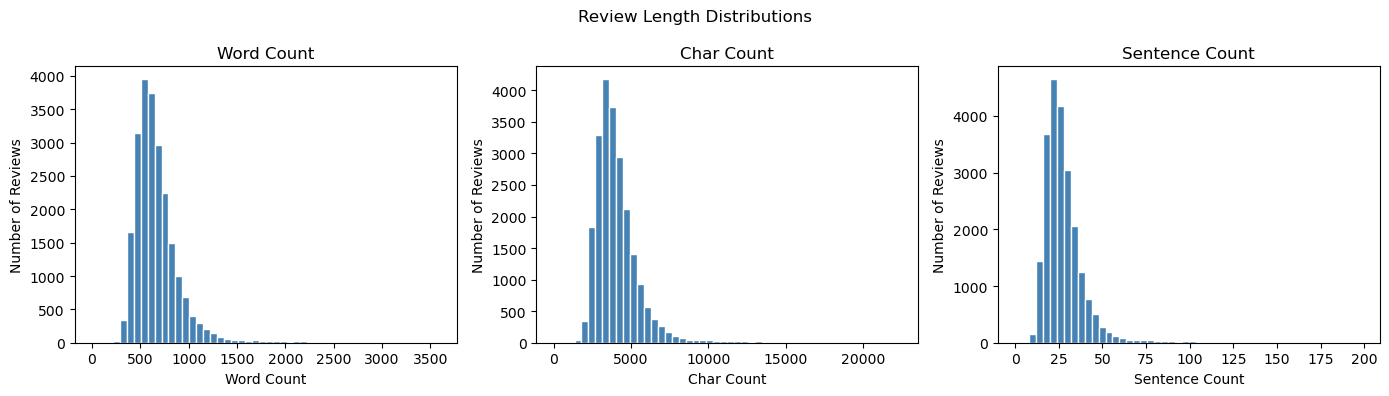

In [10]:
# Histograms of word count, character count, and sentence count.
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["word_count", "char_count", "sentence_count"]):
    ax.hist(df[col], bins=50, color="steelblue", edgecolor="white")
    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel(col.replace("_", " ").title())
    ax.set_ylabel("Number of Reviews")

fig.suptitle("Review Length Distributions")
fig.tight_layout()
plt.show()


### Score Distribution


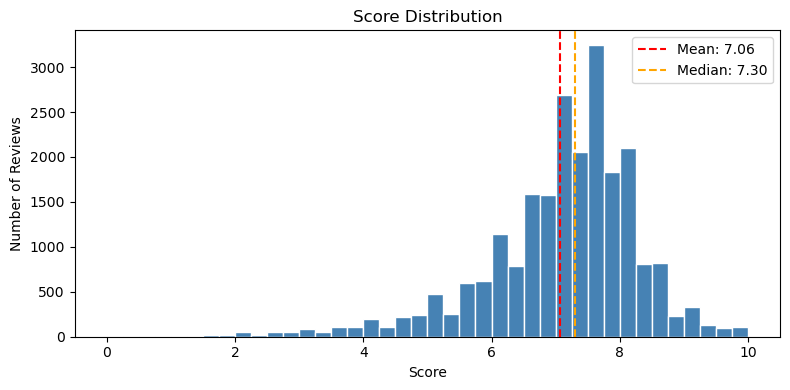

In [11]:
# Histogram of review scores with mean and median marked.
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["score"], bins=40, color="steelblue", edgecolor="white")
ax.axvline(df["score"].mean(), color="red", linestyle="--", label=f"Mean: {df['score'].mean():.2f}")
ax.axvline(df["score"].median(), color="orange", linestyle="--", label=f"Median: {df['score'].median():.2f}")
ax.set_title("Score Distribution")
ax.set_xlabel("Score")
ax.set_ylabel("Number of Reviews")
ax.legend()
plt.tight_layout()
plt.show()


### Reviews per Year


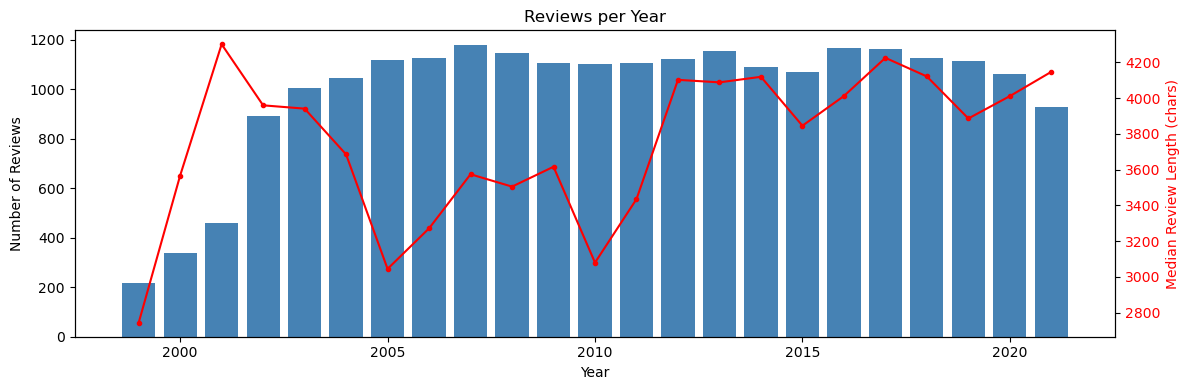

In [12]:
# Bar chart of review count per year, overlaid with median review length trend.
yearly = (
    df.assign(year=pd.to_datetime(df["pub_date"]).dt.year)
    .groupby("year")
    .agg(review_count=("review_url", "count"), median_chars=("char_count", "median"))
)

fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.bar(yearly.index, yearly["review_count"], color="steelblue", label="Review count")
ax1.set_xlabel("Year")
ax1.set_ylabel("Number of Reviews")
ax1.set_title("Reviews per Year")

ax2 = ax1.twinx()
ax2.plot(yearly.index, yearly["median_chars"], color="red", marker="o", markersize=3, label="Median length (chars)")
ax2.set_ylabel("Median Review Length (chars)", color="red")
ax2.tick_params(axis="y", labelcolor="red")

fig.tight_layout()
plt.show()


### Genre Distribution


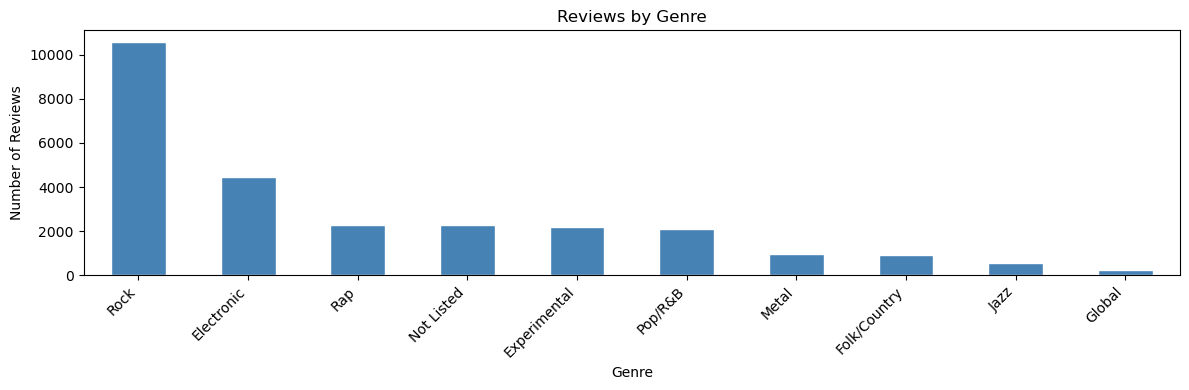

In [13]:
# Bar chart of review counts by genre; reviews with no genre tag shown as "Unknown".
genre_counts = (
    df["genres"].fillna("Not Listed")
    .str.split(", ")
    .explode()
    .value_counts()
)

fig, ax = plt.subplots(figsize=(12, 4))
genre_counts.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Reviews by Genre")
ax.set_xlabel("Genre")
ax.set_ylabel("Number of Reviews")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### Reviews per Author


Unique authors: 651
Reviews per author — mean: 35.1, median: 8, max: 857
Top 10 authors account for 25.1% of all reviews
Authors with only 1 review: 148 (22.7% of authors)


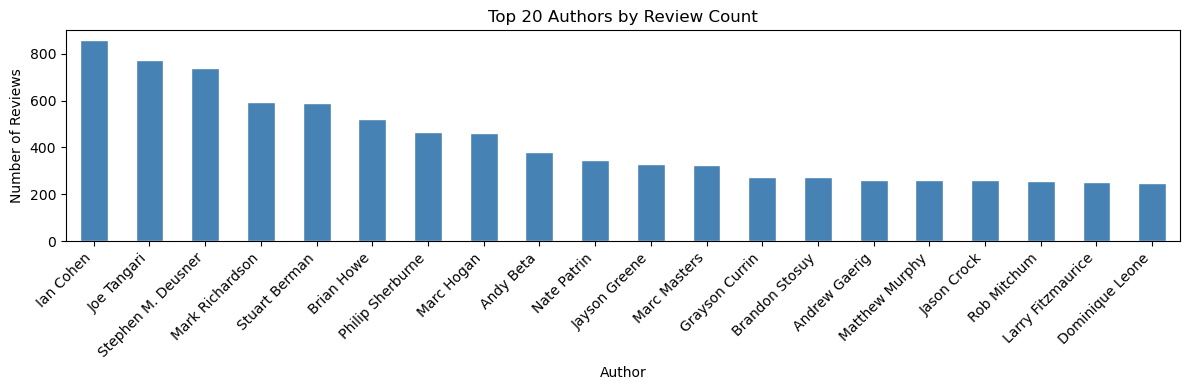

In [15]:
# Summary stats on author distribution and bar chart of top 20 most prolific reviewers.
author_counts = df["author"].value_counts()

print(f"Unique authors: {len(author_counts):,}")
print(f"Reviews per author — mean: {author_counts.mean():.1f}, median: {author_counts.median():.0f}, max: {author_counts.max()}")
print(f"Top 10 authors account for {author_counts.head(10).sum() / len(df) * 100:.1f}% of all reviews")
print(f"Authors with only 1 review: {(author_counts == 1).sum():,} ({(author_counts == 1).sum() / len(author_counts) * 100:.1f}% of authors)")

fig, ax = plt.subplots(figsize=(12, 4))
author_counts.head(20).plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Top 20 Authors by Review Count")
ax.set_xlabel("Author")
ax.set_ylabel("Number of Reviews")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### TF-IDF Top Terms by Genre

In [18]:
# TF-IDF top terms by genre: first with standard stopwords, then with music-review vocabulary removed.
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

genre_texts = (
    df[df["genres"].notna() & ~df["genres"].str.contains(",", na=False)]
    .groupby("genres")["cleaned_body"]
    .apply(" ".join)
)

def print_tfidf(title, vectorizer):
    matrix = vectorizer.fit_transform(genre_texts)
    terms = vectorizer.get_feature_names_out()
    print(f"\n{title}")
    print(f"{'Genre':<20} Top terms")
    print("-" * 80)
    for i, genre in enumerate(genre_texts.index):
        top = np.argsort(matrix[i].toarray()[0])[::-1][:8]
        print(f"{genre:<20} {', '.join(terms[top])}")

print_tfidf(
    "Standard stopwords",
    TfidfVectorizer(max_features=5000, stop_words="english")
)

custom_stopwords = list(TfidfVectorizer(stop_words="english").get_stop_words()) + [
    "album", "music", "song", "songs", "track", "tracks", "sound", "sounds",
    "like", "just", "band", "new", "time", "work", "one", "make", "way"
]
print_tfidf(
    "Music-review stopwords removed",
    TfidfVectorizer(max_features=5000, stop_words=custom_stopwords)
)



Standard stopwords
Genre                Top terms
--------------------------------------------------------------------------------
Electronic           like, music, album, sound, track, tracks, sounds, just
Experimental         like, music, album, sound, sounds, new, work, just
Folk/Country         like, album, songs, music, song, guitar, just, folk
Global               music, album, like, band, sound, songs, song, guitar
Jazz                 jazz, like, music, album, band, new, time, sound
Metal                metal, like, band, album, black, music, death, songs
Pop/R&B              like, album, pop, music, song, songs, love, just
Rap                  like, album, rap, just, music, new, song, rapper
Rock                 like, album, band, songs, song, rock, music, just

Music-review stopwords removed
Genre                Top terms
--------------------------------------------------------------------------------
Electronic           record, pop, house, dance, techno, bass, electronic, 

## Save Cleaned Data

In [19]:
# Filter to reviews with at least 200 characters and save to CSV.
df_clean = df[df["char_count"] >= 200].copy()
df_clean.to_csv(DATA_DIR / "pitchfork_reviews_cleaned.csv", index=False)
print(f"Saved {len(df_clean):,} reviews to {DATA_DIR / 'pitchfork_reviews_cleaned.csv'}")


Saved 22,853 reviews to ../datasets/pitchfork_reviews_cleaned.csv
